## 1. Scraping Dataset
Melakukan scraping data "Top Anime" dari website MyAnimeList menggunakan library BeautifulSoup dan requests. Data yang berhasil dikumpulkan (seperti judul, peringkat, skor, jumlah member, jumlah episode, dan tipe tayangan) disimpan ke dalam file format .csv agar proses eksplorasi bisa dilakukan tanpa perlu menarik data dari server berulang kali.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

print("Memulai scraping dengan BeautifulSoup (Mengekstrak 7 Kolom)...")

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'
}

results = []

for limit in range(0, 1550, 50):
    url = f"https://myanimelist.net/topanime.php?limit={limit}"
    
    try:
        response = requests.get(url, headers=headers)
        
        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            anime_rows = soup.find_all('tr', class_='ranking-list')
            
            for row in anime_rows:
                title_tag = row.find('h3', class_='anime_ranking_h3')
                title = title_tag.a.text if title_tag else "Unknown"
                
                score_tag = row.find('td', class_='score')
                score = score_tag.text.strip() if score_tag else None

                rank_tag = row.find('td', class_='rank')
                rank = rank_tag.text.strip() if rank_tag else None

                info_tag = row.find('div', class_='information')
                tipe = None
                eps = None
                aired = None
                members = None
                
                if info_tag:
                    info_text = info_tag.text.strip().split('\n')
                    if len(info_text) >= 1:
                        tipe_eps = info_text[0].strip()
                        if '(' in tipe_eps:
                            tipe = tipe_eps.split('(')[0].strip()
                            eps = tipe_eps.split('(')[1].replace('eps)', '').replace('ep)', '').strip()
                        else:
                            tipe = tipe_eps
                            eps = 'Unknown'

                    if len(info_text) >= 2:
                        aired = info_text[1].strip()

                    if len(info_text) >= 3:
                        members = info_text[2].strip()

                results.append({
                    'Rank': rank,
                    'Title': title,
                    'Score': score,
                    'Type': tipe,
                    'Episodes': eps,
                    'Aired_Date': aired,
                    'Members': members
                })
                
            print(f"Data dari limit {limit} berhasil ditarik.")
        else:
            print(f"Error {response.status_code} pada limit {limit}. Diblokir oleh server.")
            break
            
    except Exception as e:
        print(f"Gagal mengambil limit {limit}: {e}")
        
    time.sleep(3)

df = pd.DataFrame(results)
df.to_csv('mal_topanime.csv', index=False)
print(f"\nScraping selesai! Terkumpul {len(df)} baris data dan {df.shape[1]} kolom.")
display(df.head())

## 2. Import dan Pemahaman Dataset
Mengimpor dataset hasil scraping menggunakan library pandas. Karena data hasil scraping web masih berbentuk teks mentah (String), dilakukan tahap Pembersihan Data (Data Cleaning) untuk mengubah teks menjadi format numerik. Setelah bersih, dilakukan identifikasi terhadap struktur, dimensi, dan tipe data dari masing-masing atribut.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('mal_topanime.csv')
df['Members'] = df['Members'].astype(str).str.replace(',', '').str.replace(' members', '')
df['Members'] = pd.to_numeric(df['Members'], errors='coerce')
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
df['Episodes'] = pd.to_numeric(df['Episodes'], errors='coerce')
df['Release_Year'] = df['Aired_Date'].str.extract(r'(\d{4})').astype(float)
display(df.head())

print("\nInfo Umum")
info_df = pd.DataFrame({
    'Nama Kolom': df.columns,
    'Tipe Data': df.dtypes.astype(str).values,
    'Jumlah Non-Null': df.count().values
})
display(info_df)

print(f"\nDimensi Data: {df.shape[0]} Baris, {df.shape[1]} Kolom")

,Rank,Title,Score,Type,Episodes,Aired_Date,Members,Release_Year
0,1,Sousou no Frieren,9.25,TV,28.0,Sep 2023 - Mar 2024,1512841,2023.0
1,2,Fullmetal Alchemist: Brotherhood,9.11,TV,64.0,Apr 2009 - Jul 2010,3733561,2009.0
2,3,Re:Zero kara Hajimeru Isekai Seikatsu 4th Season,9.11,TV,19.0,Apr 2026 - Sep 2026,326531,2026.0
3,4,Steel Ball Run: JoJo no Kimyou na Bouken,9.08,ONA,NaN,Mar 2026 -,232906,2026.0
4,5,Bleach: Sennen Kessen-hen - Kashin-tan,9.07,TV,10.0,Jul 2026 -,162216,2026.0



Info Umum


,Nama Kolom,Tipe Data,Jumlah Non-Null
0,Rank,int64,1550
1,Title,str,1550
2,Score,float64,1550
3,Type,str,1550
4,Episodes,float64,1540
5,Aired_Date,str,1550
6,Members,int64,1550
7,Release_Year,float64,1550



Dimensi Data: 1550 Baris, 8 Kolom


## 3. Analisis Statistik dan Kualitas Data
Menghitung statistik deskriptif dasar (seperti rata-rata, median, standar deviasi) untuk atribut numerik, dan melihat distribusi frekuensi untuk atribut kategorikal. Pada tahap ini juga dilakukan pengecekan terhadap nilai yang hilang (missing values) serta pendeteksian data pencilan (outlier) menggunakan metode jangkauan antar-kuartil (IQR).

In [2]:
print("Statistik Deskriptif")
display(df[['Score', 'Members', 'Episodes', 'Release_Year']].describe())

print("\nDistribusi Atribut Kategorikal")
display(df['Type'].value_counts())

print("\nMissing Values")
print(df.isnull().sum())

Q1 = df['Episodes'].quantile(0.25)
Q3 = df['Episodes'].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier_eps = df[(df['Episodes'] < batas_bawah) | (df['Episodes'] > batas_atas)]
print(f"\nDeteksi Outlier pada 'Episodes'")
print(f"Batas Atas Episode: {batas_atas:.0f} episode")
print(f"Jumlah anime outlier (episode sangat panjang): {len(outlier_eps)}")

Statistik Deskriptif


,Score,Members,Episodes,Release_Year
count,1550.000000,1.550000e+03,1540.000000,1550.000000
mean,8.061019,3.720365e+05,18.664286,2014.338710
std,0.312636,5.546298e+05,56.488123,9.865172
min,7.670000,8.590000e+02,1.000000,1970.000000
25%,7.810000,5.140150e+04,1.000000,2009.000000
50%,7.990000,1.560175e+05,12.000000,2016.000000
75%,8.250000,4.339565e+05,22.000000,2022.000000
max,9.250000,4.423994e+06,1787.000000,2026.000000



Distribusi Atribut Kategorikal


Type
TV            817
Movie         351
ONA           167
OVA           120
Special        55
TV Special     40
Name: count, dtype: int64


Missing Values
Rank             0
Title            0
Score            0
Type             0
Episodes        10
Aired_Date       0
Members          0
Release_Year     0
dtype: int64

Deteksi Outlier pada 'Episodes'
Batas Atas Episode: 54 episode
Jumlah anime outlier (episode sangat panjang): 65


## 4. Visualisasi Data
Membuat representasi grafis menggunakan library matplotlib dan seaborn untuk mempermudah identifikasi pola data. Visualisasi mencakup analisis univariat (melihat distribusi satu variabel tunggal menggunakan histogram dan bar chart) serta analisis bivariat (melihat hubungan antar variabel menggunakan scatter plot, boxplot, dan heatmap).

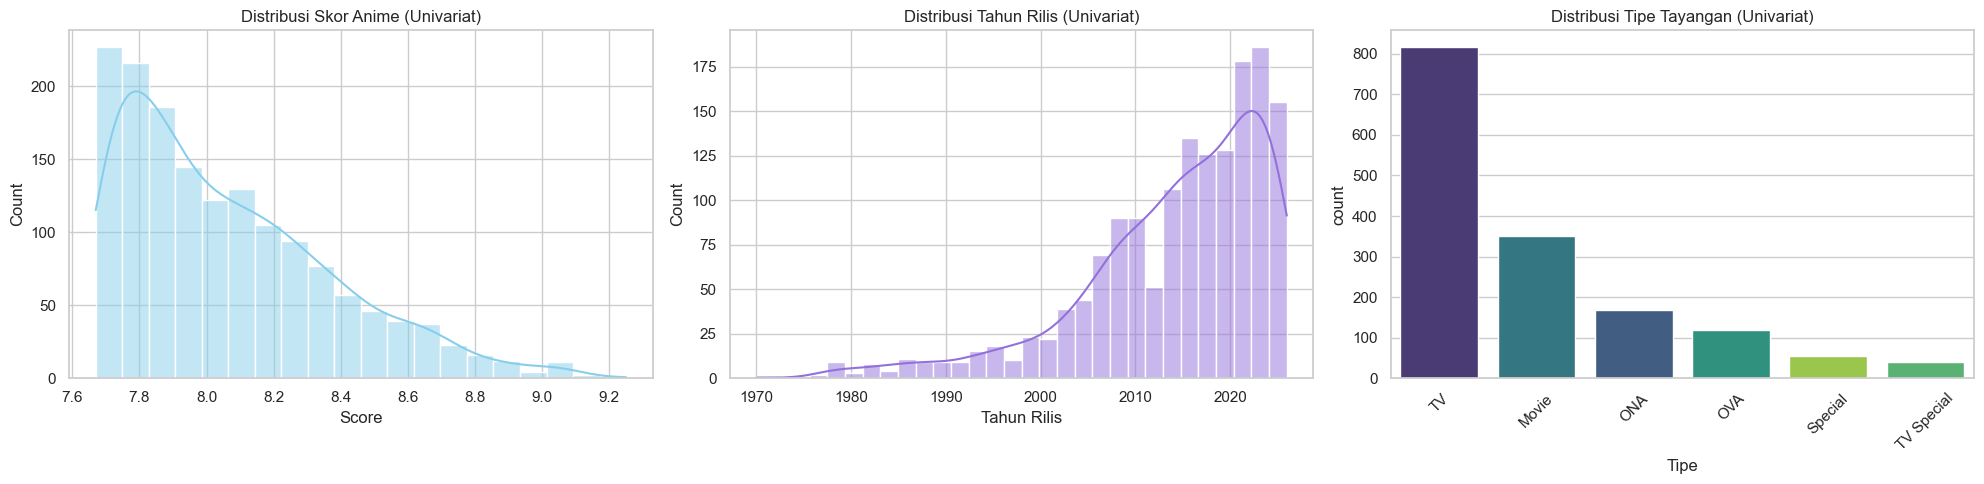

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
sns.histplot(df['Score'].dropna(), kde=True, color='skyblue', bins=20, ax=ax[0])
ax[0].set_title('Distribusi Skor Anime (Univariat)')
ax[0].set_xlabel('Score')

sns.histplot(df['Release_Year'].dropna(), kde=True, color='mediumpurple', bins=30, ax=ax[1])
ax[1].set_title('Distribusi Tahun Rilis (Univariat)')
ax[1].set_xlabel('Tahun Rilis')

sns.countplot(data=df, x='Type', hue='Type', palette='viridis', ax=ax[2], 
              order=df['Type'].value_counts().index, legend=False)
ax[2].set_title('Distribusi Tipe Tayangan (Univariat)')
ax[2].set_xlabel('Tipe')
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

* **Histogram (Score):** Distribusi skor condong ke arah kanan (menumpuk di nilai tinggi). Mayoritas anime dalam dataset ini memiliki skor di kisaran 7.5 hingga 8.5. Hal ini sangat wajar karena populasi data ini murni ditarik dari halaman "Top Anime" (tayangan dengan kualitas terbaik).

* **Histogram (Release Year):** Distribusi menumpuk secara drastis di sebelah kanan (tahun modern). Ini menunjukkan bahwa mayoritas dari tayangan yang masuk ke jajaran anime terbaik dirilis di atas tahun 2010.

* **Bar Chart (Type):** Format tayangan TV merupakan yang paling mendominasi daftar klasemen, menunjukkan bahwa format serial bersambung lebih populer dan lebih banyak mendapatkan respons ulasan positif dibandingkan tayangan berdurasi pendek seperti OVA.

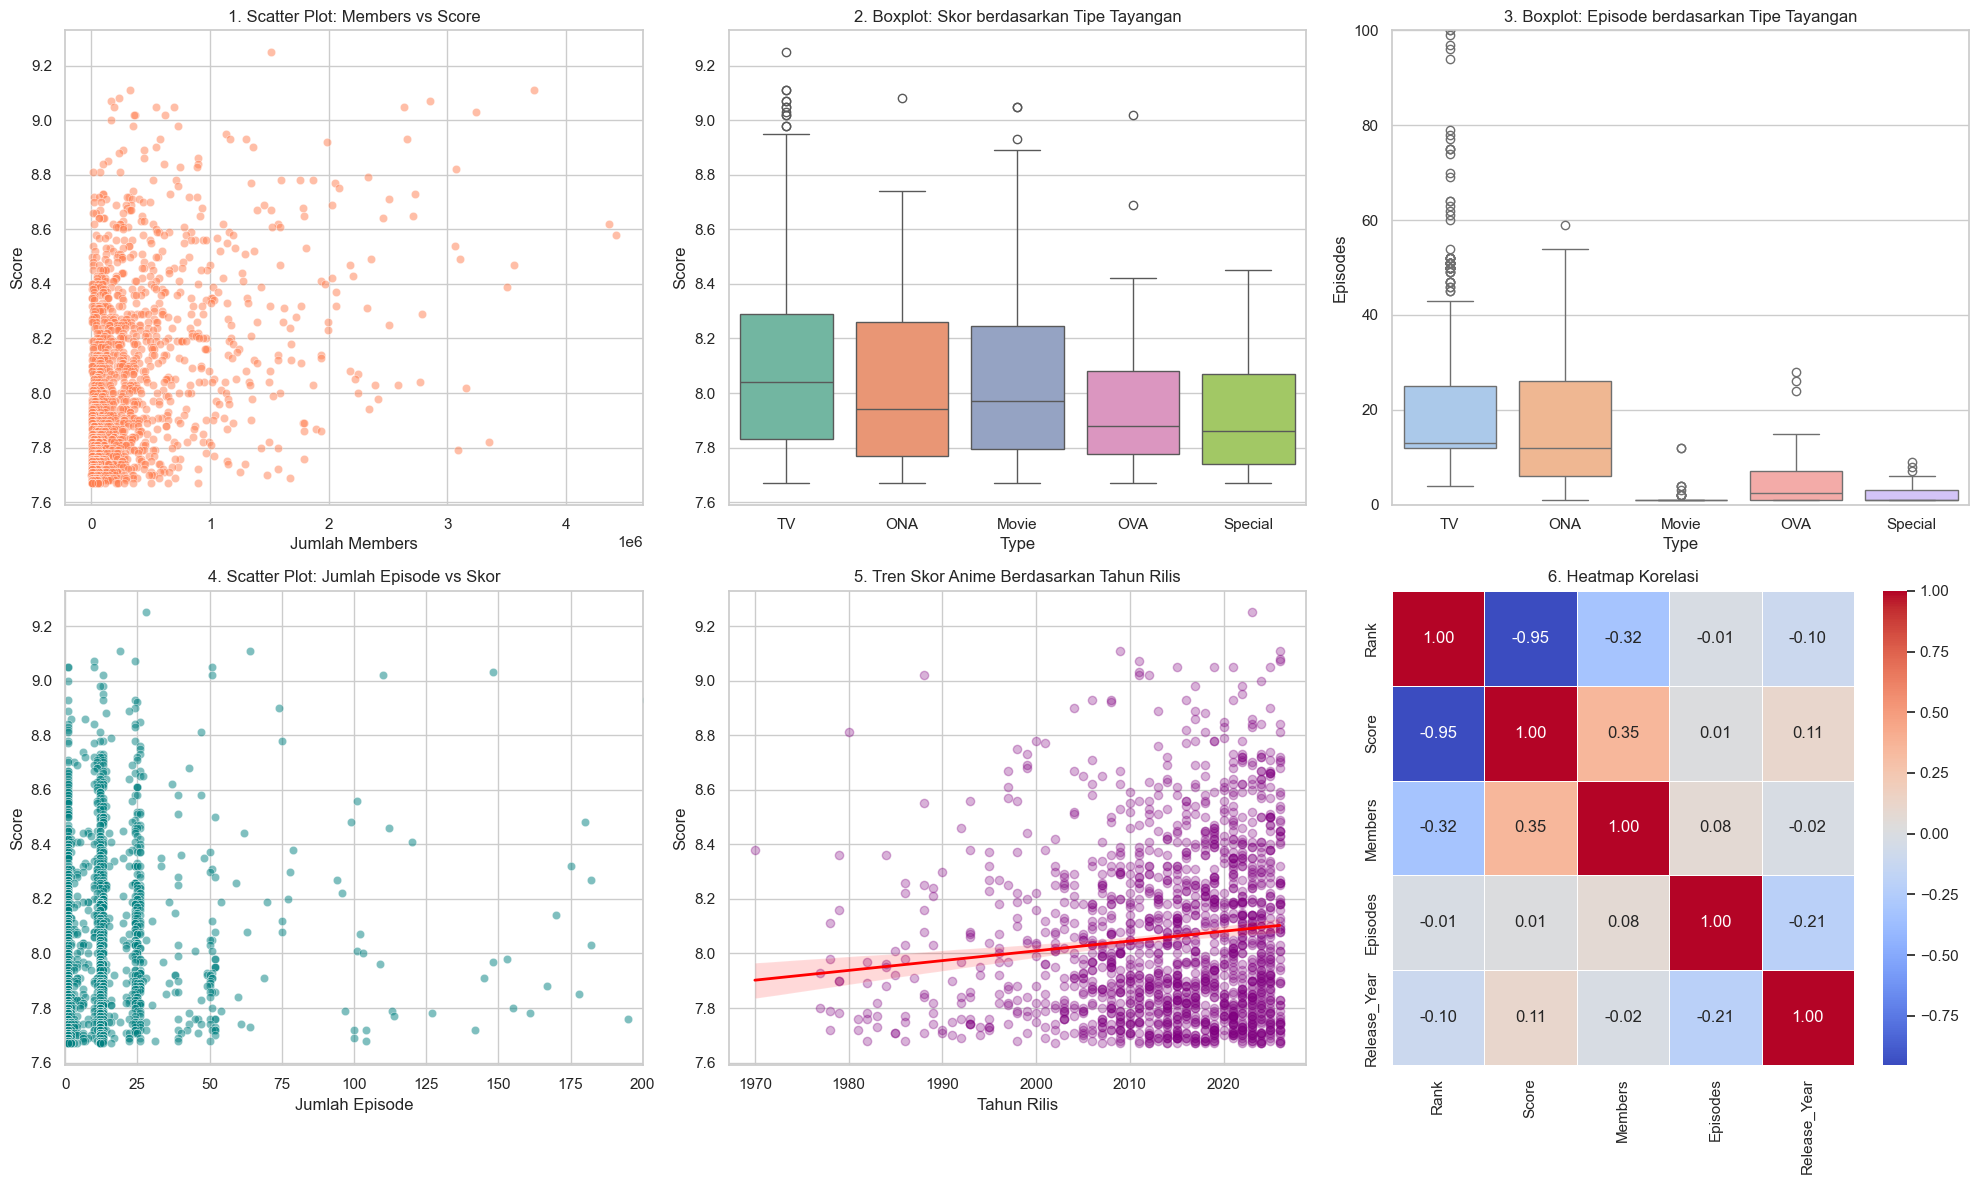

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(20, 12))
top_types = df['Type'].value_counts().head(5).index
df_top = df[df['Type'].isin(top_types)]

sns.scatterplot(data=df, x='Members', y='Score', alpha=0.5, color='coral', ax=ax[0, 0])
ax[0, 0].set_title('1. Scatter Plot: Members vs Score')
ax[0, 0].set_xlabel('Jumlah Members')

sns.boxplot(data=df_top, x='Type', y='Score', hue='Type', palette='Set2', ax=ax[0, 1], legend=False)
ax[0, 1].set_title('2. Boxplot: Skor berdasarkan Tipe Tayangan')

sns.boxplot(data=df_top, x='Type', y='Episodes', hue='Type', palette='pastel', ax=ax[0, 2], legend=False)
ax[0, 2].set_title('3. Boxplot: Episode berdasarkan Tipe Tayangan')
ax[0, 2].set_ylim(0, 100)

sns.scatterplot(data=df, x='Episodes', y='Score', alpha=0.5, color='teal', ax=ax[1, 0])
ax[1, 0].set_title('4. Scatter Plot: Jumlah Episode vs Skor')
ax[1, 0].set_xlim(0, 200)
ax[1, 0].set_xlabel('Jumlah Episode')

sns.regplot(data=df, x='Release_Year', y='Score', 
            scatter_kws={'alpha':0.3, 'color':'purple'}, 
            line_kws={'color':'red', 'linewidth':2}, ax=ax[1, 1])
ax[1, 1].set_title('5. Tren Skor Anime Berdasarkan Tahun Rilis')
ax[1, 1].set_xlabel('Tahun Rilis')

corr_matrix = df[['Rank', 'Score', 'Members', 'Episodes', 'Release_Year']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax[1, 2])
ax[1, 2].set_title('6. Heatmap Korelasi')

plt.tight_layout()
plt.show()

* **Grafik 1 (Members vs Score):** Terdapat korelasi positif yang nyata. Semakin tinggi jumlah Members (popularitas sebuah anime), rata-rata skornya cenderung mengerucut pada angka yang lebih tinggi. Anime dengan skor di atas 8.5 hampir selalu memiliki basis penonton masif.

* **Grafik 2 (Score berdasarkan Tipe):** Walaupun seri TV memiliki jumlah produksi terbanyak, nilai median skornya (garis tengah pada kotak) bersaing sangat ketat dengan format Movie. Ini menunjukkan bahwa tayangan teatrikal (Movie) secara umum mampu menjaga standar kualitas penyutradaraan yang tinggi sehingga jarang mendapat rating buruk di jajaran "Top Anime".

* **Grafik 3 (Episode berdasarkan Tipe):** Grafik ini mempertegas perbedaan struktural tiap format. Movie dan OVA memiliki sebaran episode yang sangat sempit (terpusat di angka 1 hingga 3), sedangkan TV memiliki rentang (IQR) yang sangat lebar, umumnya berkisar antara 12 hingga 24 episode per musimnya.

* **Grafik 4 (Episode vs Score):** Apakah anime yang lebih panjang pasti lebih bagus? Scatter plot ini menjawab tidak. Titik-titik skor tertinggi justru menumpuk (padat) pada anime dengan rentang 12 hingga 24 episode (standar musiman). Anime berdurasi sangat panjang (>100 episode) tidak menjamin perolehan skor yang lebih tinggi.

* **Grafik 5 (Tren Tahun Rilis vs Score):** Garis regresi berwarna merah menunjukkan tren yang cenderung mendatar (stabil) dari tahun ke tahun. Ini berarti tidak ada ketimpangan standar penilaian antara anime era klasik (jadul) dengan anime era modern. Keduanya dinilai secara adil oleh pengguna.

* **Grafik 6 (Heatmap Korelasi):** Memvalidasi secara matematis seluruh penemuan di atas. Members memiliki korelasi positif kuat terhadap Score. Sebaliknya, Episodes memiliki nilai korelasi yang sangat mendekati 0 terhadap Score, mengonfirmasi kesimpulan dari Grafik 4 bahwa panjang cerita tidak memengaruhi tinggi-rendahnya rating.